### PH464/564: Scientific Computing II
___

# Homework 4
### Due: Mon, Oct 20th at 11:59pm Pacific
---

The purpose of this assignment is to use the Metropolis algorithm to infer model parameters by sampling a _posterior distribution_.  Let's return to our linear regression problem.

Using the synthetic $x-y$ data set from [Hogg, Bovy, and Lang (2010)](https://arxiv.org/abs/1008.4686) (in the `data` directory of this repo), assume a **uniform prior** over slope and y-intercept and use the Metropolis algorithm to draw samples from the posterior density function describing our knowledge of the slope and y-intercept given the observed data.

To do this you will have to extend our 1-D Markov chains from class to 2-D, meaning we have a 2-D parameter space to explore and you will have to decide a method (or methods) to propose moves in those two dimensions.

Show the quality of the fit to the data and the associated uncertainty by plotting the lines corresponding to several samples from your chain on top of the data

Make one or several figures showing your estimate of the 2-D posterior distribution.  Are there correlations between the model parameters?

## Graduate Students

Use the same technique for constraining a linear model connecting the color and brightness of nearby main sequence stars observed by Gaia (parallax > 40 mas).  To do this you will need to:

1. Select only the stars from the data set with parallax > 40 mas.
2. (crudely) remove the white dwarfs (constructing a dividing line by eye is fine for this).
3. Define your likelihood.  This will be similar to the last linear regression likelihood, except that we don't have uncertainties on measurements of the brightness, Mg.  Even if we did, the scatter about the linear relationship is due to physics not measurement uncertainty, so we'll need to infer it from the data.
4. Define priors.  Uniform priors on slope and y-intercept are fine, but you'll need to impose a prior on the scatter in $M_G$ about the line, $\sigma_{M_G}$, that ensures it stays positive and doesn't run away.  I suggest a normal distribution with $\sigma \sim 5$ for $\sigma_{M_G} > 0$.
5. Perform your first 3-D MCMC.

Show the quality of the fit to the data and the associated uncertainty by plotting the lines corresponding to several samples from your chain on top of the data.

Are there correlations between the constraints on the model parameters?

What did we infer regarding the scatter about the line, $\sigma_{M_G}$, and how does it compare to your by-eye assessment of the width of the scatter along the main sequence?

## Problem 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.distributions import norm
import scipy.stats as stats
import corner

In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 12}
plt.rc('font', **font)

In [3]:
data = pd.read_csv('./data/data_yerr.dat', delimiter=' & ')
data

/tmp/ipykernel_973/2953653994.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv('./data/data_yerr.dat', delimiter=' & ')


,# index,x,y,sigm_y
0,1,201,592,61
1,2,244,401,25
2,3,47,583,38
3,4,287,402,15
4,5,203,495,21
5,6,58,173,15
6,7,210,479,27
7,8,202,504,14
8,9,198,510,30
9,10,158,416,16


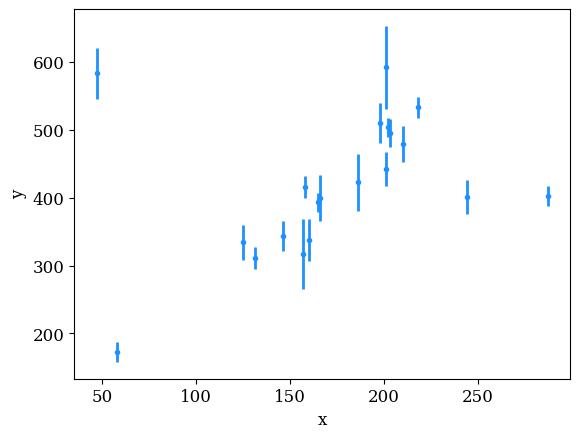

In [4]:
plt.errorbar(data['x'], data['y'], yerr=data['sigm_y'], marker='.', linewidth=0, elinewidth=2, color='dodgerblue')
plt.xlabel('x')
plt.ylabel('y');

# save limits for later use
xlim = plt.xlim()

plt.show()

In [5]:
def build_model(m, b):
    def model(x):
        return m * x + b
    return model

def lnlikelihood(m, b, x=data['x'], y=data['y'], sigma_y=data['sigm_y']):
    model = build_model(m, b)
    lnlike = -0.5*np.sum(np.log(2*np.pi*sigma_y**2)) - np.sum((y - model(x))**2/(2*sigma_y**2)) 
    return lnlike

In [6]:
# from linear regression notebook: best fit modelis y = 1.08 x + 213.27
m0 = 1.0
b0 = 200.0

m = m0
b = b0
p_current = lnlikelihood(m, b)

chain_m = [m]
chain_b = [b]
probs = [p_current]

In [7]:
niter = 50000
sigma_m = 0.05
sigma_b = 5.0

for i in range(niter):
    mp = norm.rvs(loc=m, scale=sigma_m)
    bp = norm.rvs(loc=b, scale=sigma_b)
    p_p = lnlikelihood(mp, bp)
    
    α = p_p - p_current # originally p_p/p_current
    u = np.random.uniform()
    accepted = u < np.exp(α)
    
    # print(mp, bp, p_p, α, u, np.exp(α))
    
    if accepted:
        m = mp
        b = bp
        p_current = p_p
        
    chain_m.append(m)
    chain_b.append(b)
    probs.append(p_current)

In [8]:
print(p_p, p_current, α)
print(np.exp(p_p)/np.exp(p_current))
print(p_p - p_current)
print(np.exp(p_p - p_current))

-230.79065955548248 -230.79065955548248 -0.10717872393013295
1.0
0.0
1.0


In [9]:
print(len(chain_m))

50001


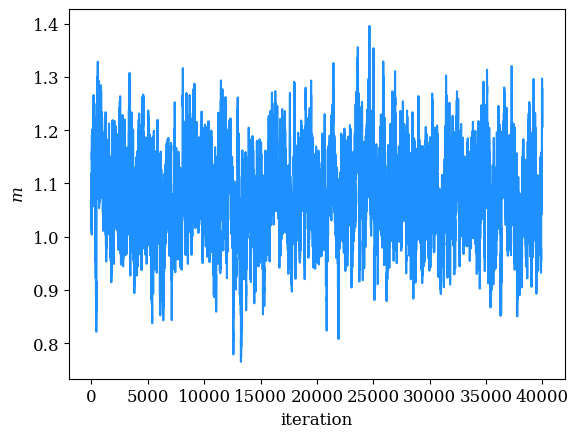

In [10]:
burnin_length = 10000

plt.plot(chain_m[burnin_length:], color='dodgerblue')
plt.xlabel('iteration')
plt.ylabel('$m$');

plt.show()

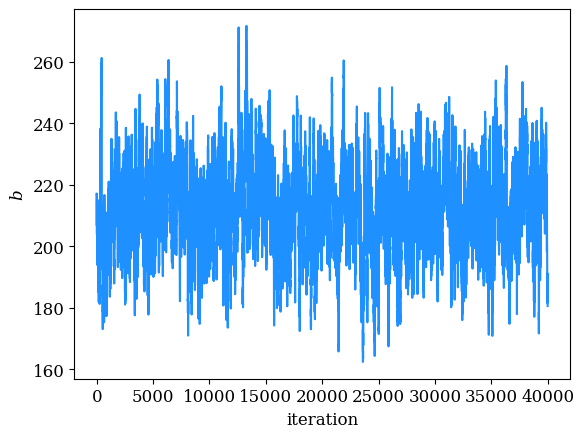

In [11]:
plt.plot(chain_b[burnin_length:], color='dodgerblue')
plt.xlabel('iteration')
plt.ylabel('$b$');

plt.show()

In [12]:
m_samples = np.array(chain_m[burnin_length:])
b_samples = np.array(chain_b[burnin_length:])

In [13]:
mean_m = np.mean(m_samples)
med_m = np.median(m_samples)
std_m = np.std(m_samples)

mean_b = np.mean(b_samples)
med_b = np.median(b_samples)
std_b = np.std(b_samples)

print(f'm statistics: mean of {round(mean_m,4)}, median of {round(med_m,4)}, standard deviation of {round(std_m,4)}')
print(f'b statistics: mean of {round(mean_b,4)}, median of {round(med_b,4)}, standard deviation of {round(std_b,4)}')

m statistics: mean of 1.0812, median of 1.0817, standard deviation of 0.0793
b statistics: mean of 212.4439, median of 212.1918, standard deviation of 14.8359


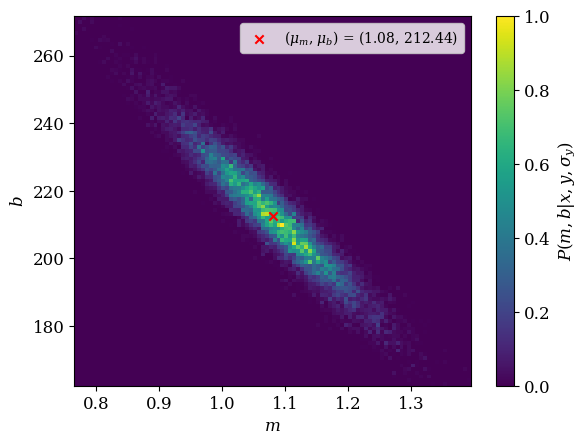

In [14]:
plt.hist2d(m_samples, b_samples, bins=100)
plt.scatter([mean_m], [mean_b], marker='x', color='r', label=fr'($\mu_m$, $\mu_b$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$)');

plt.xlabel('$m$')
plt.ylabel('$b$')
plt.colorbar(label=r'$P(m,b|x,y,\sigma_y)$')
plt.legend(fontsize='small')

plt.show()

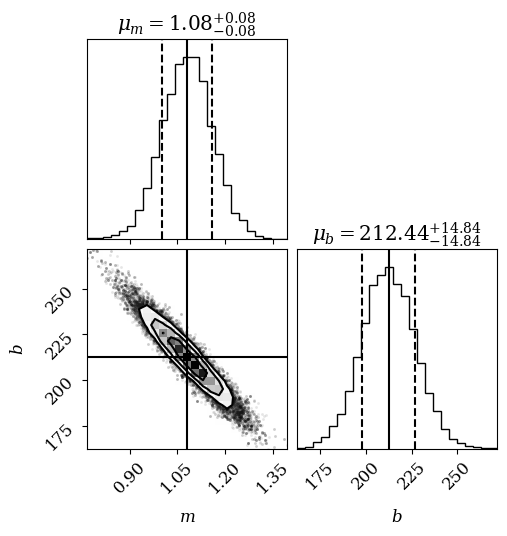

In [15]:
samples = np.column_stack([m_samples, b_samples])

ndim = 2

fig = corner.corner(samples, bins=25, quantiles=(0.16, 0.84), labels=[r'$m$', r'$b$'])
ax = np.array(fig.axes).reshape((ndim, ndim))

ax[0,0].axvline(mean_m, color='k', label='mean')
ax[1,1].axvline(mean_b, color='k')

ax[1,0].axvline(mean_m, color='k')
ax[1,0].axhline(mean_b, color='k')

ax[0,0].set_title(fr'$\mu_m = {round(mean_m,2)}^{{+{round(std_m,2)}}}_{{-{round(std_m,2)}}}$')
ax[1,1].set_title(fr'$\mu_b = {round(mean_b,2)}^{{+{round(std_b,2)}}}_{{-{round(std_b,2)}}}$')

plt.show()

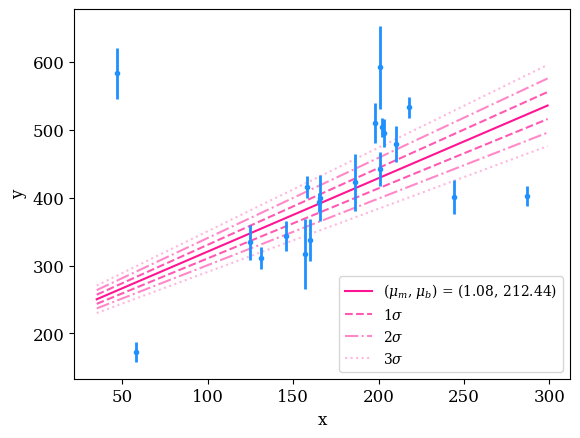

In [16]:
xlow, xhigh = xlim
test_x = np.linspace(xlow, xhigh, 20)
best_fit_model = build_model(mean_m, mean_b)
sigma1_pos_model = build_model(mean_m+sigma_m,mean_b+sigma_b)
sigma1_neg_model = build_model(mean_m-sigma_m,mean_b-sigma_b)
sigma2_pos_model = build_model(mean_m+2*sigma_m,mean_b+2*sigma_b)
sigma2_neg_model = build_model(mean_m-2*sigma_m,mean_b-2*sigma_b)
sigma3_pos_model = build_model(mean_m+3*sigma_m,mean_b+3*sigma_b)
sigma3_neg_model = build_model(mean_m-3*sigma_m,mean_b-3*sigma_b)

plt.plot(test_x, best_fit_model(test_x), color='deeppink',  label=fr'($\mu_m$, $\mu_b$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$)')
plt.plot(test_x, sigma1_pos_model(test_x), color='deeppink',  label=r'$1\sigma$', linestyle='--', alpha=0.7) ## need to work on this later
plt.plot(test_x, sigma1_neg_model(test_x), color='deeppink', linestyle='--', alpha=0.7)
plt.plot(test_x, sigma2_pos_model(test_x), color='deeppink',  label=r'$2\sigma$', linestyle='-.', alpha=0.5)
plt.plot(test_x, sigma2_neg_model(test_x), color='deeppink', linestyle='-.', alpha=0.5)
plt.plot(test_x, sigma3_pos_model(test_x), color='deeppink',  label=r'$3\sigma$', linestyle=':', alpha=0.3)
plt.plot(test_x, sigma3_neg_model(test_x), color='deeppink', linestyle=':', alpha=0.3)

plt.errorbar(data['x'], data['y'], yerr=data['sigm_y'], marker='.', linewidth=0, elinewidth=2, color='dodgerblue')
plt.xlabel('x')
plt.ylabel('y')

plt.legend(loc='lower right', fontsize='small')

plt.show()

[28004 35729 12939]


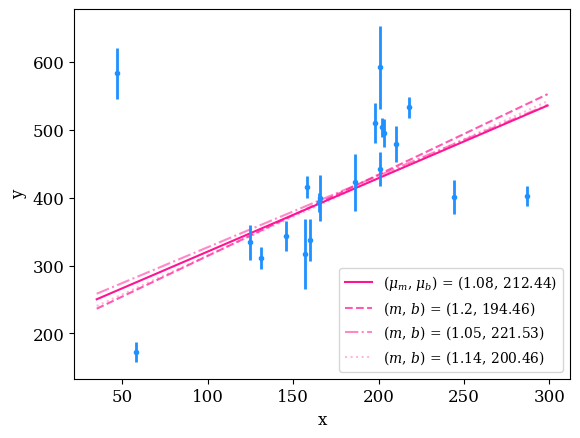

In [17]:
sample_index = np.random.randint(low=0, high=len(m_samples), size=3)
print(sample_index)

model_1 = build_model(m_samples[sample_index[0]],b_samples[sample_index[0]])
model_2 = build_model(m_samples[sample_index[1]],b_samples[sample_index[1]])
model_3 = build_model(m_samples[sample_index[2]],b_samples[sample_index[2]])

plt.plot(test_x, best_fit_model(test_x), color='deeppink',  label=fr'($\mu_m$, $\mu_b$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$)')
plt.plot(test_x, model_1(test_x), color='deeppink', label=fr'($m$, $b$) = (${round(m_samples[sample_index[0]],2)}$, ${round(b_samples[sample_index[0]],2)}$)', 
         linestyle='--', alpha=0.7) 
plt.plot(test_x, model_2(test_x), color='deeppink', label=fr'($m$, $b$) = (${round(m_samples[sample_index[1]],2)}$, ${round(b_samples[sample_index[1]],2)}$)', 
         linestyle='-.', alpha=0.5)
plt.plot(test_x, model_3(test_x), color='deeppink', label=fr'($m$, $b$) = (${round(m_samples[sample_index[2]],2)}$, ${round(b_samples[sample_index[2]],2)}$)', 
         linestyle=':', alpha=0.3)

plt.errorbar(data['x'], data['y'], yerr=data['sigm_y'], marker='.', linewidth=0, elinewidth=2, color='dodgerblue')
plt.xlabel('x')
plt.ylabel('y')

plt.legend(loc='lower right', fontsize='small')

plt.show()

In [18]:
corr = np.corrcoef(m_samples, b_samples)
print(f'correlation matrix:\n{corr}')
print(f'correlation between m and b: {corr[0,1]}')

correlation matrix:
[[ 1.         -0.94926587]
 [-0.94926587  1.        ]]
correlation between m and b: -0.9492658657905917


## Problem 2

In [19]:
df = pd.read_csv('../../hub_data_share/gaiadr3_solar_neighborhood.csv')
df

,mg,bp_rp,parallax
0,10.390250,2.731872,10.000008
1,8.608481,2.025819,10.000029
2,4.267759,0.880858,10.000032
3,10.506658,2.649735,10.000066
4,12.077941,2.940875,10.000111
...,...,...,...
227624,11.758283,2.834036,336.026602
227625,9.521769,2.215609,392.752945
227626,14.129570,4.184836,415.179416
227627,11.883816,2.833697,546.975940


In [20]:
nearby_sel = df.parallax > 40.
nearby_df = df[nearby_sel]

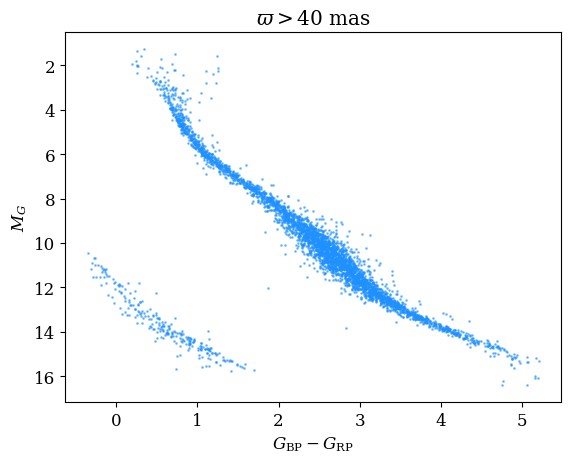

In [21]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='dodgerblue')
plt.gca().invert_yaxis()
plt.title(r'$\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.show()

In [22]:
print(min(nearby_df.bp_rp), max(nearby_df.mg))

-0.34853935 16.40824032082896


In [23]:
wd_color = (-0.4, 1.8)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) &
    (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

main_df = nearby_df[~wd_sel]

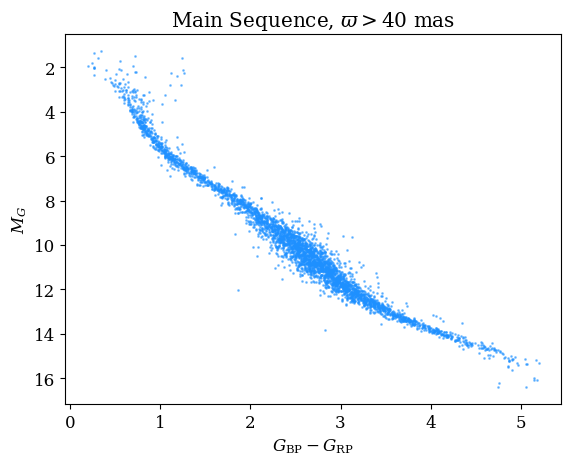

In [24]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='dodgerblue')
plt.gca().invert_yaxis()
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")
# save limits for later use
xlim = plt.xlim()
ylim = plt.ylim()

plt.show()

In [25]:
def lnL_star(m, b, sigma_y, x=main_df['bp_rp'], y=main_df['mg']):
    model = build_model(m, b)
    
    N = len(y)
    lnlike = -0.5*N*np.log(2*np.pi*sigma_y**2) - np.sum((y - model(x))**2/(2*sigma_y**2))
    return lnlike

In [26]:
x=main_df['bp_rp']
y=main_df['mg']

m0 = 4.0
b0 = -1.0
sigma_mg0 = stats.halfnorm.rvs(loc=10,scale=5)

m = m0
b = b0
sigma_mg = sigma_mg0
p_current = lnL_star(m, b, sigma_mg)
# p_current = lnlikelihood(m, b, x, y, sigma_y=sigma_mg)

chain_m = [m]
chain_b = [b]
chain_sigma = [sigma_mg]
probs = [p_current]

In [27]:
niter = 100000
sigma_m = 0.1
sigma_b = 0.1
sigma = 0.1

for i in range(niter):
    mp = norm.rvs(loc=m, scale=sigma_m)
    bp = norm.rvs(loc=b, scale=sigma_b)
    sigma_p = norm.rvs(loc=sigma_mg, scale=sigma)
    p_pm = lnL_star(mp, b, sigma_mg)
    p_pb = lnL_star(m, bp, sigma_mg)
    p_ps = lnL_star(m, b, sigma_p)
    # p_p = lnlikelihood(mp, bp, x, y, sigma_y=sigma_p)
    
    α_m = p_pm - p_current # originally p_p/p_current
    α_b = p_pb - p_current
    α_s = p_ps - p_current
    u = np.random.uniform()

    if α_m >= 0:
        accepted_m = True
    else:
        accepted_m = np.log(u) < α_m
    if α_b >= 0:
        accepted_b = True
    else:
        accepted_b = np.log(u) < α_b
    if α_s >= 0:
        accepted_s = True
    else:
        accepted_s = np.log(u) < α_s
    # print(mp, bp, p_p, α, u, np.exp(α))
    
    if accepted_m:
        m = mp
    if accepted_b:
        b = bp
    if accepted_s:
        sigma_mg = sigma_p
        
    p_current = lnL_star(m, b, sigma_mg)
        
    chain_m.append(m)
    chain_b.append(b)
    chain_sigma.append(sigma_mg)
    probs.append(p_current)

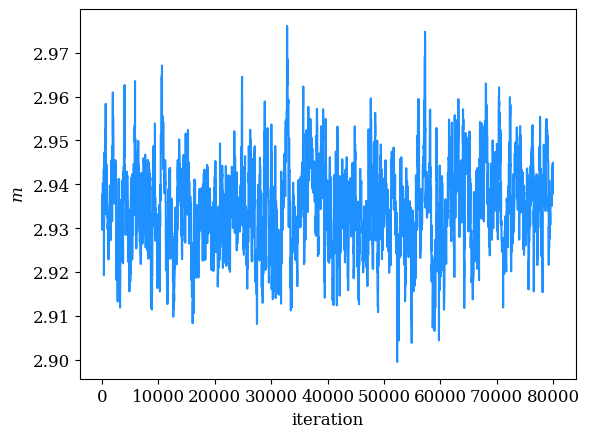

In [28]:
burnin_length = 20000

plt.plot(chain_m[burnin_length:], color='dodgerblue')
plt.xlabel('iteration')
plt.ylabel('$m$');

plt.show()

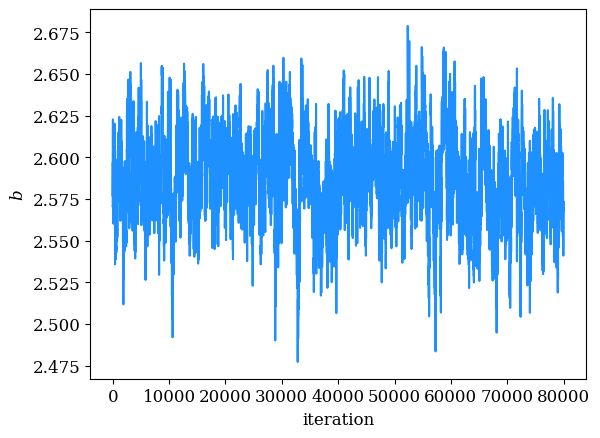

In [29]:
plt.plot(chain_b[burnin_length:], color='dodgerblue')
plt.xlabel('iteration')
plt.ylabel('$b$');

plt.show()

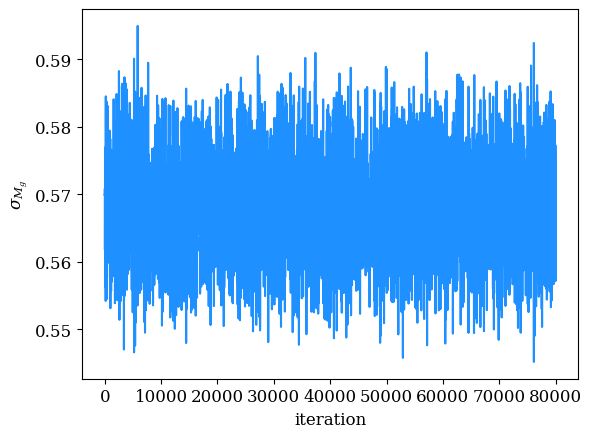

In [30]:
plt.plot(chain_sigma[burnin_length:], color='dodgerblue')
plt.xlabel('iteration')
plt.ylabel(r'$\sigma_{M_g}$');

plt.show()

In [31]:
m_samples = np.array(chain_m[burnin_length:])
b_samples = np.array(chain_b[burnin_length:])
sigma_mg_samples = np.array(chain_sigma[burnin_length:])

In [32]:
mean_m = np.mean(m_samples)
med_m = np.median(m_samples)
std_m = np.std(m_samples)

mean_b = np.mean(b_samples)
med_b = np.median(b_samples)
std_b = np.std(b_samples)

mean_sigmg = np.mean(sigma_mg_samples)
med_sigmg = np.median(sigma_mg_samples)
std_sigmg = np.std(sigma_mg_samples)

print(f'm statistics: mean of {round(mean_m,4)}, median of {round(med_m,4)}, standard deviation of {round(std_m,4)}')
print(f'b statistics: mean of {round(mean_b,4)}, median of {round(med_b,4)}, standard deviation of {round(std_b,4)}')
print(f'sigma_mg statistics: mean of {round(mean_sigmg,4)}, median of {round(med_sigmg,4)}, standard deviation of {round(std_sigmg,4)}')

m statistics: mean of 2.9348, median of 2.9347, standard deviation of 0.0098
b statistics: mean of 2.5877, median of 2.5884, standard deviation of 0.026
sigma_mg statistics: mean of 0.5681, median of 0.5681, standard deviation of 0.0065


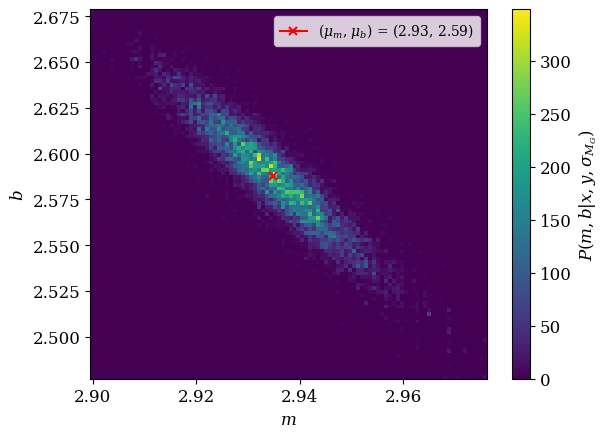

In [76]:
plt.hist2d(m_samples, b_samples, bins=100)
plt.errorbar([mean_m], [mean_b], marker='x', color='r', markeredgewidth=1.5,
             label=fr'($\mu_m$, $\mu_b$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$)');

plt.xlabel('$m$')
plt.ylabel('$b$')
plt.colorbar(label=r'$P(m,b|x,y,\sigma_{M_G})$')
plt.legend(fontsize='small')

plt.show()

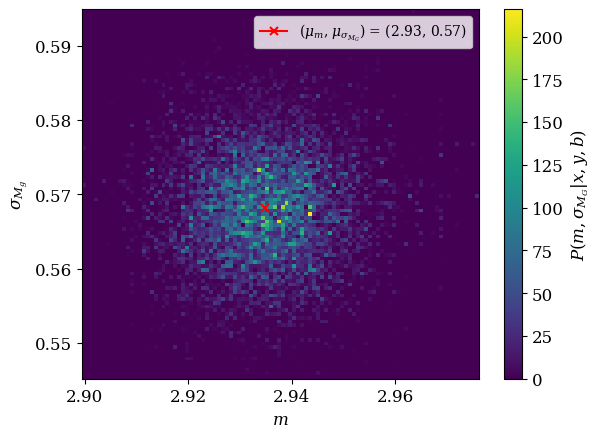

In [77]:
plt.hist2d(m_samples, sigma_mg_samples, bins=100)
plt.errorbar([mean_m], [mean_sigmg], marker='x', color='r', markeredgewidth=1.5,
             label=fr'($\mu_m$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m,2)}$, ${round(mean_sigmg,2)}$)');

plt.xlabel('$m$')
plt.ylabel(r'$\sigma_{M_g}$')
plt.colorbar(label=r'$P(m,\sigma_{M_G}|x,y,b)$')
plt.legend(fontsize='small')

plt.show()

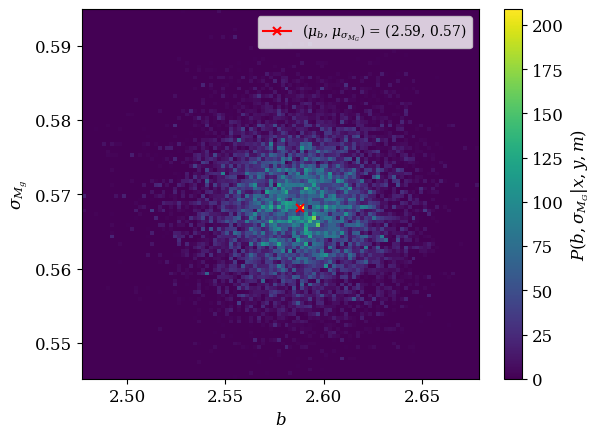

In [79]:
plt.hist2d(b_samples, sigma_mg_samples, bins=100)
plt.errorbar([mean_b], [mean_sigmg], marker='x', color='r', markeredgewidth=1.5,
             label=fr'($\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_b,2)}$, ${round(mean_sigmg,2)}$)');

plt.xlabel('$b$')
plt.ylabel(r'$\sigma_{M_g}$')
plt.colorbar(label=r'$P(b,\sigma_{M_G}|x,y,m)$')
plt.legend(fontsize='small')

plt.show()

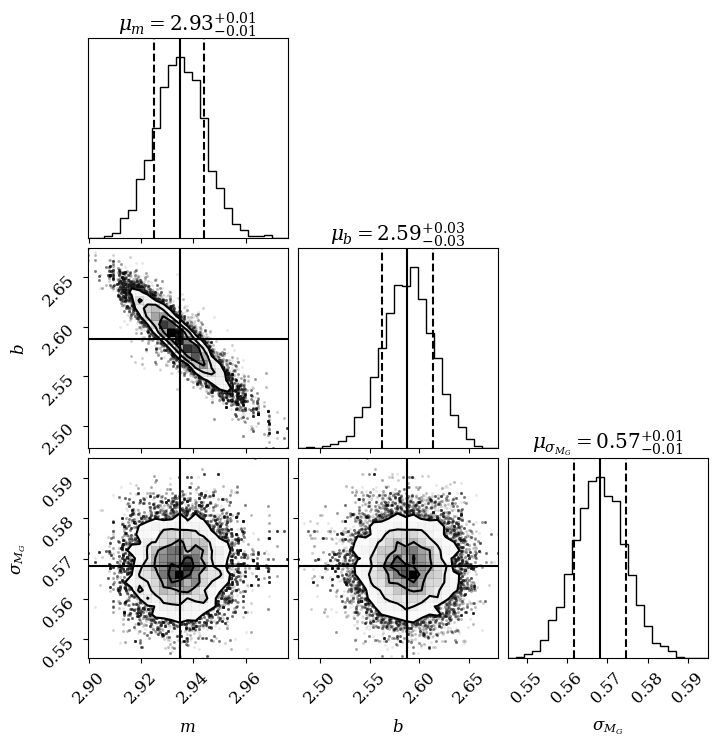

In [36]:
samples = np.column_stack([m_samples, b_samples, sigma_mg_samples])

ndim = 3

fig = corner.corner(samples, bins=25, quantiles=(0.16, 0.84), labels=[r'$m$', r'$b$', r'$\sigma_{M_G}$'])
ax = np.array(fig.axes).reshape((ndim, ndim))

ax[0,0].axvline(mean_m, color='k', label='mean')
ax[1,1].axvline(mean_b, color='k')
ax[2,2].axvline(mean_sigmg, color='k')

ax[1,0].axvline(mean_m, color='k')
ax[1,0].axhline(mean_b, color='k')

ax[2,0].axvline(mean_m, color='k')
ax[2,0].axhline(mean_sigmg, color='k')

ax[2,1].axvline(mean_b, color='k')
ax[2,1].axhline(mean_sigmg, color='k')

ax[0,0].set_title(fr'$\mu_m = {round(mean_m,2)}^{{+{round(std_m,2)}}}_{{-{round(std_m,2)}}}$')
ax[1,1].set_title(fr'$\mu_b = {round(mean_b,2)}^{{+{round(std_b,2)}}}_{{-{round(std_b,2)}}}$')
ax[2,2].set_title(fr'$\mu_{{\sigma_{{M_G}}}} = {round(mean_sigmg,2)}^{{+{round(std_sigmg,2)}}}_{{-{round(std_sigmg,2)}}}$')

plt.show()

[53974  4126  2389]


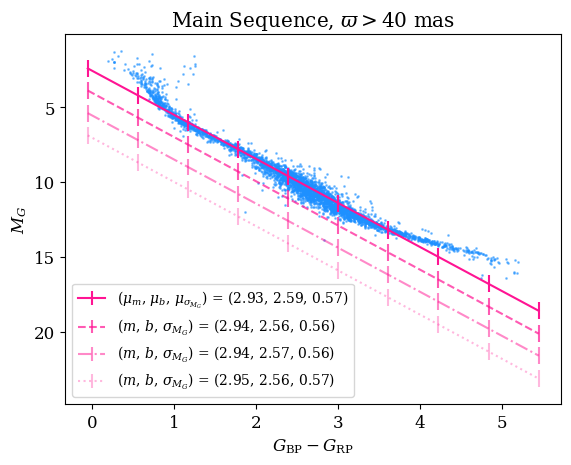

In [80]:
xlow, xhigh = xlim
test_x = np.linspace(xlow, xhigh, 10)
best_fit_model = build_model(mean_m, mean_b)

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='dodgerblue')

sample_index = np.random.randint(low=0, high=len(m_samples), size=3)
print(sample_index)

model_1 = build_model(m_samples[sample_index[0]],b_samples[sample_index[0]])
model_2 = build_model(m_samples[sample_index[1]],b_samples[sample_index[1]])
model_3 = build_model(m_samples[sample_index[2]],b_samples[sample_index[2]])

plt.errorbar(test_x, best_fit_model(test_x), yerr=mean_sigmg, color='deeppink',  
             label=fr'($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$, ${round(mean_sigmg,2)}$)')
plt.errorbar(test_x, 1.5+model_1(test_x), yerr=sigma_mg_samples[sample_index[0]], color='deeppink', linestyle='--', alpha=0.7,
             label=fr'($m$, $b$, $\sigma_{{M_G}}$) = (${round(m_samples[sample_index[0]],2)}$, ${round(b_samples[sample_index[0]],2)}$, ${round(sigma_mg_samples[sample_index[0]],2)}$)') 
plt.errorbar(test_x, 3+model_2(test_x), yerr=sigma_mg_samples[sample_index[1]], color='deeppink', linestyle='-.', alpha=0.5,
             label=fr'($m$, $b$, $\sigma_{{M_G}}$) = (${round(m_samples[sample_index[1]],2)}$, ${round(b_samples[sample_index[1]],2)}$, ${round(sigma_mg_samples[sample_index[1]],2)}$)')
plt.errorbar(test_x, 4.5+model_3(test_x), yerr=sigma_mg_samples[sample_index[2]], color='deeppink', linestyle=':', alpha=0.3,
             label=fr'($m$, $b$, $\sigma_{{M_G}}$) = (${round(m_samples[sample_index[2]],2)}$, ${round(b_samples[sample_index[2]],2)}$, ${round(sigma_mg_samples[sample_index[2]],2)}$)')

plt.gca().invert_yaxis()
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.legend(loc='lower left', fontsize='small')

plt.show()

In [47]:
corr_mb = np.corrcoef(m_samples, b_samples)
corr_ms = np.corrcoef(m_samples, sigma_mg_samples)
corr_bs = np.corrcoef(b_samples, sigma_mg_samples)
print(f'correlation matrix between m and b:\n{corr_mb}')
print(f'correlation matrix between m and sigma_mg:\n{corr_ms}')
print(f'correlation matrix between b and sigma_mg:\n{corr_bs}')

correlation matrix between m and b:
[[ 1.         -0.92902931]
 [-0.92902931  1.        ]]
correlation matrix between m and sigma_mg:
[[1.         0.02579188]
 [0.02579188 1.        ]]
correlation matrix between b and sigma_mg:
[[ 1.         -0.02482297]
 [-0.02482297  1.        ]]
